### **importação bibliotecas pandas e matplot**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### **guardando na variável `df` o csv do dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/lorenzozoppelletto/financial-risk-for-loan-approval/Loan.csv')

### **criando gráfico simples para ver a distribuição de Aprovado (1) e Reprovado (2)**

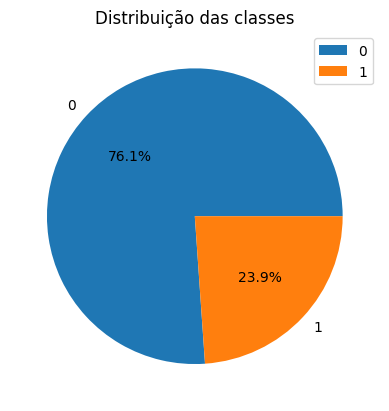

In [3]:
plt.pie(df['LoanApproved'].value_counts(), labels=df['LoanApproved'].value_counts().index, autopct='%1.1f%%')
plt.legend(df['LoanApproved'].value_counts().index)
plt.title('Distribuição das classes')
plt.show()

### **método info para ver principais informações (tipos, colunas, linhas, não nulos)**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

### **método isnull para verificar os valores nulos e somando-os**

In [5]:
df.isnull().sum()

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

### **método drop para excluir colunas desnecessárias**

In [6]:
df = df.drop(columns= ['ApplicationDate', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose'])

### **acessando atributo do `df` para verificar nomes das colunas**

In [7]:
df.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'Experience',
       'LoanAmount', 'LoanDuration', 'NumberOfDependents',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults',
       'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='object')

### **transforma a coluna EmploymentStatus (texto) em colunas númericas (one-hot encoding) e substitui a coluna original por uma lista com os valores one-hot de cada linha, junta as colunas one-hot separadas de volta ao dataframe original**

In [8]:
df_encoded = pd.get_dummies(df['EmploymentStatus'], columns=['EmploymentStatus'], dtype=int)
df['EmploymentStatus'] = df_encoded.values.tolist()
df = pd.concat([df, df_encoded], axis=1)
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,...,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,Employed,Self-Employed,Unemployed
0,45,39948,617,"[1, 0, 0]",22,13152,48,2,183,0.354418,...,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,1,0,0
1,38,39709,628,"[1, 0, 0]",15,26045,48,1,496,0.087827,...,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,1,0,0
2,47,40724,570,"[1, 0, 0]",26,17627,36,2,902,0.137414,...,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,1,0,0
3,58,69084,545,"[1, 0, 0]",34,37898,96,1,755,0.267587,...,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,1,0,0
4,37,103264,594,"[1, 0, 0]",17,9184,36,1,274,0.320535,...,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,1,0,0
